Propagating FULL PERTURBATIONS for 30 days...

  MISSION ANALYSIS: PARAMETERS VARIATION AFTER 30 DAYS (SSO)
  Model: 10x10 Gravity, Atm Drag, SRP, Luni-Solar Third Body
1. SEMI-MAJOR AXIS (a)
   Initial: 7178.137 km
   Final:   7174.315 km
   Delta:   -3821.52 meters (-3.821524 km) ((Drag Decay))
--------------------------------------------------------------------
2. ECCENTRICITY (e)
   Initial: 0.001000
   Final:   0.001060
   Delta:   0.000060 (Periodic oscillation J3/SRP/Third Body prevailing over secular drag effect)
--------------------------------------------------------------------
3. INCLINATION (i)
   Initial: 98.60000 deg
   Final:   98.68065 deg
   Delta:   0.08065 deg (Micro-oscillation)
--------------------------------------------------------------------
4. RAAN (Ω)
   Initial: 0.000 deg
   Final:   29.640 deg (Standard Modulo 360)
            29.640 deg (Real Propagated Value)
   Delta:   29.640 deg (Normalized real drift)
-------------------------------------------------

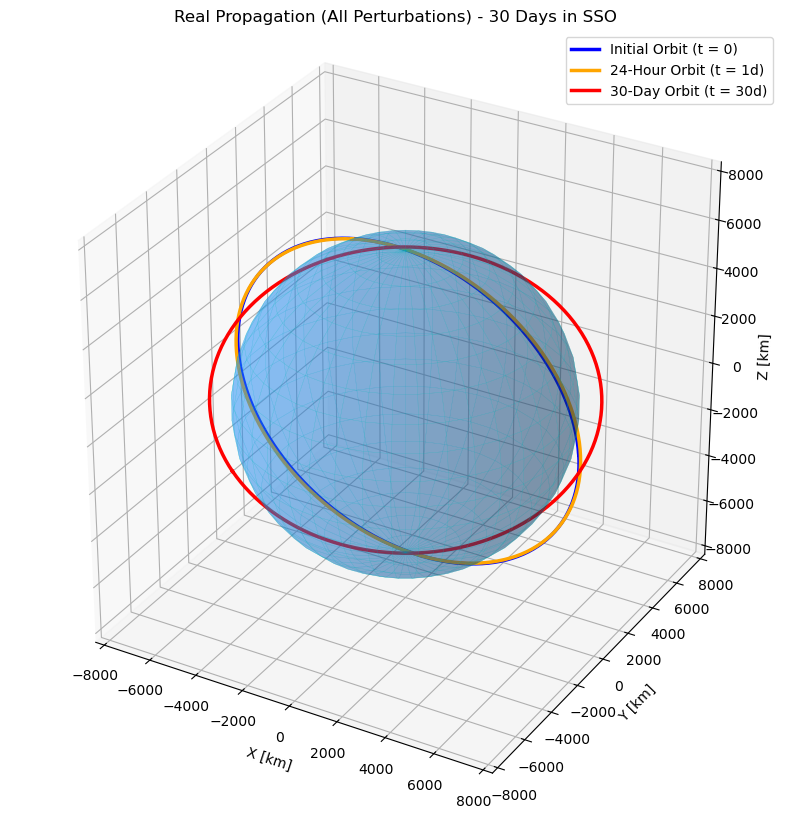

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState

from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient

# ==========================================
# 2. TIME AND FRAMES DEFINITION
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, 
                               Constants.WGS84_EARTH_FLATTENING, 
                               earth_frame)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. ORBIT CREATION (SSO at 800 km)
# ==========================================
h = 800e3
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + h
e = 0.001
i = math.radians(98.6)
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 850.0) # Mass 850 kg

# ==========================================
# 4. PROPAGATOR CONFIGURATION
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

ephemeris_generator = propagator.getEphemerisGenerator()

# ==========================================
# 5. ADDING ALL PERTURBATIONS
# ==========================================
# EGM96 Gravity (10x10 harmonics)
gravity_provider = GravityFieldFactory.getNormalizedProvider(10, 10)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# Third Body (Sun and Moon)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
propagator.addForceModel(ThirdBodyAttraction(sun))
propagator.addForceModel(ThirdBodyAttraction(moon))

# Atmosphere (Drag)
atmosphere = HarrisPriester(sun, earth_shape)
propagator.addForceModel(DragForce(atmosphere, IsotropicDrag(15.0, 2.2)))

# Solar Radiation Pressure (SRP)
propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(15.0, 1.8)))

# ==========================================
# 6. PROPAGATION (30 DAYS)
# ==========================================
days = 30.0
duration = days * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagating FULL PERTURBATIONS for {int(days)} days...")
final_state = propagator.propagate(final_date)

ephemeris = ephemeris_generator.getGeneratedEphemeris()
state_24h = ephemeris.propagate(initial_date.shiftedBy(24.0 * 3600.0))

orbit_24h = KeplerianOrbit(state_24h.getOrbit())
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 7. MISSION ANALYSIS REPORT
# ==========================================
# Extraction of final dimensional parameters
a_fin = orbit_30d.getA()
e_fin = orbit_30d.getE()
i_fin = math.degrees(orbit_30d.getI())

# Extraction of raw values (actual propagated values, which may be negative or > 360)
raan_fin_raw = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())
omega_fin_raw = math.degrees(orbit_30d.getPerigeeArgument())

# Standardized values using modulo 360 for classic Keplerian notation
raan_fin_mod = raan_fin_raw % 360.0
omega_fin_mod = omega_fin_raw % 360.0

# Calculation of normalized physical delta (effective shift relative to zero, between -180° and +180°)
delta_raan = (raan_fin_raw - math.degrees(raan) + 180.0) % 360.0 - 180.0
delta_omega = (omega_fin_raw - math.degrees(omega) + 180.0) % 360.0 - 180.0

print("\n====================================================================")
print(f"  MISSION ANALYSIS: PARAMETERS VARIATION AFTER {int(days)} DAYS (SSO)")
print("  Model: 10x10 Gravity, Atm Drag, SRP, Luni-Solar Third Body")
print("====================================================================")
print(f"1. SEMI-MAJOR AXIS (a)")
print(f"   Initial: {a/1000:.3f} km")
print(f"   Final:   {a_fin/1000:.3f} km")
print(f"   Delta:   {(a_fin - a):.2f} meters ({(a_fin - a)/1000:.6f} km) ((Drag Decay))")
print("--------------------------------------------------------------------")
print(f"2. ECCENTRICITY (e)")
print(f"   Initial: {e:.6f}")
print(f"   Final:   {e_fin:.6f}")
print(f"   Delta:   {e_fin - e:.6f} (Periodic oscillation J3/SRP/Third Body prevailing over secular drag effect)")
print("--------------------------------------------------------------------")
print(f"3. INCLINATION (i)")
print(f"   Initial: {math.degrees(i):.5f} deg")
print(f"   Final:   {i_fin:.5f} deg")
print(f"   Delta:   {i_fin - math.degrees(i):.5f} deg (Micro-oscillation)")
print("--------------------------------------------------------------------")
print(f"4. RAAN (\u03A9)")
print(f"   Initial: {math.degrees(raan):.3f} deg")
print(f"   Final:   {raan_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"            {raan_fin_raw:.3f} deg (Real Propagated Value)")
print(f"   Delta:   {delta_raan:.3f} deg (Normalized real drift)")
print("--------------------------------------------------------------------")
print(f"5. ARGUMENT OF PERIGEE (\u03C9)")
print(f"   Initial: {math.degrees(omega):.3f} deg")
print(f"   Final:   {omega_fin_mod:.3f} deg (Standard Modulo 360)")
print(f"            {omega_fin_raw:.3f} deg (Real Propagated Value)")
print(f"   Delta:   {delta_omega:.3f} deg (Apsidal line rotation)")
print("====================================================================\n")

# ==========================================
# 8. 3D VISUALIZATION
# ==========================================
print("Generating 3D plot...")
orbital_period = 6050.0  

def extract_orbit(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

x0, y0, z0 = extract_orbit(0, orbital_period)                                   
x1, y1, z1 = extract_orbit(86400, 86400 + orbital_period)                       
x30, y30, z30 = extract_orbit(duration - orbital_period, duration)              

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Initial Orbit (t = 0)')
ax.plot(x1, y1, z1, color='orange', linewidth=2.5, label='24-Hour Orbit (t = 1d)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, label='30-Day Orbit (t = 30d)')

lim = R_E_km + 2000
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Real Propagation (All Perturbations) - 30 Days in SSO')
ax.legend(loc='upper right')

plt.show()